# Task 1: Exploratory Data Analysis

First import necessary libraries for loading and and examining data. Then print the first few rows of data along with dataset information and descriptions.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

wine = pd.read_csv("winequality-red.csv")

print()

print("---------------First Few Rows of the Dataset---------------")
print()
print(wine.head())
print()

print("--------------------Dataset Information--------------------")
print()
print(wine.info())
print()

print("--------------------Dataset Description--------------------")
print()
print(wine.describe())
print()


---------------First Few Rows of the Dataset---------------

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0 


The data consists of 12 columns. 

11 features: 

Fixed Acidity, Volatile Acidity, Citric Acid, Residual Sugar, Chlorides, Free SO_2, Total SO_2, Density, PH, Sulphates, and Alcohol

1 Output:

Quality

From the data, there are 1599 data entries, all features are floating point values and the output variable is an integer value.
There are no null null values in the data.

The quality (output variable) of each entry ranges from 3 to 8.

### 1b.) Distribution of Features

Create histograms for each feature to show the distribution for each data entry.

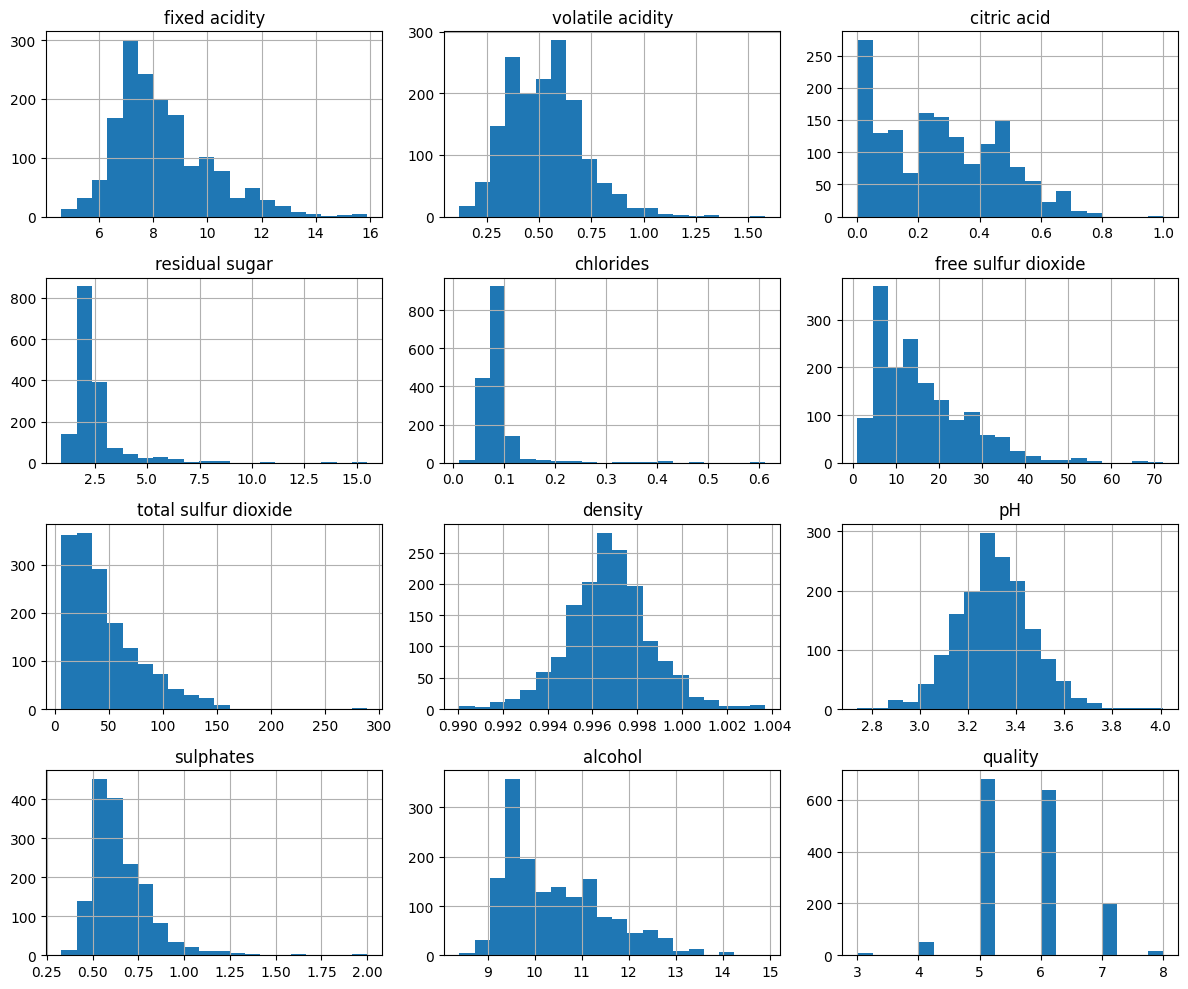

In [4]:
wine.hist(bins = 20, figsize = (12, 10))
plt.tight_layout()
plt.show()

From the histograms shown above, most features are unimodal and still somewhat spread out. 

There are a couple of features that are noticeably concentrated around one point as well.

The two most common outputs for the dataset are 5 and 6 both being roughly equal in volume and together make up much more than half of the total output variables.

Residual sugar, chlorides, and free SO_2 are very skewed. This could mean outliers in the data in these features.

### 2.) Data Quality Issues

Now look for missing values in the data as well as any duplicate entries.

In [9]:
print("Null values by feature:")
print(wine.isnull().sum())
print()

print("Total Duplicate Entries:", wine.duplicated().sum())

Null values by feature:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Total Duplicate Entries: 240


In the dataset, there are no null values for any feature of any entry.

However, as seen above, the dataset has 240 duplicate entries.

### 3.) Relationships Between Variables

A heatmap will be used to discover any possible relationships between variables.

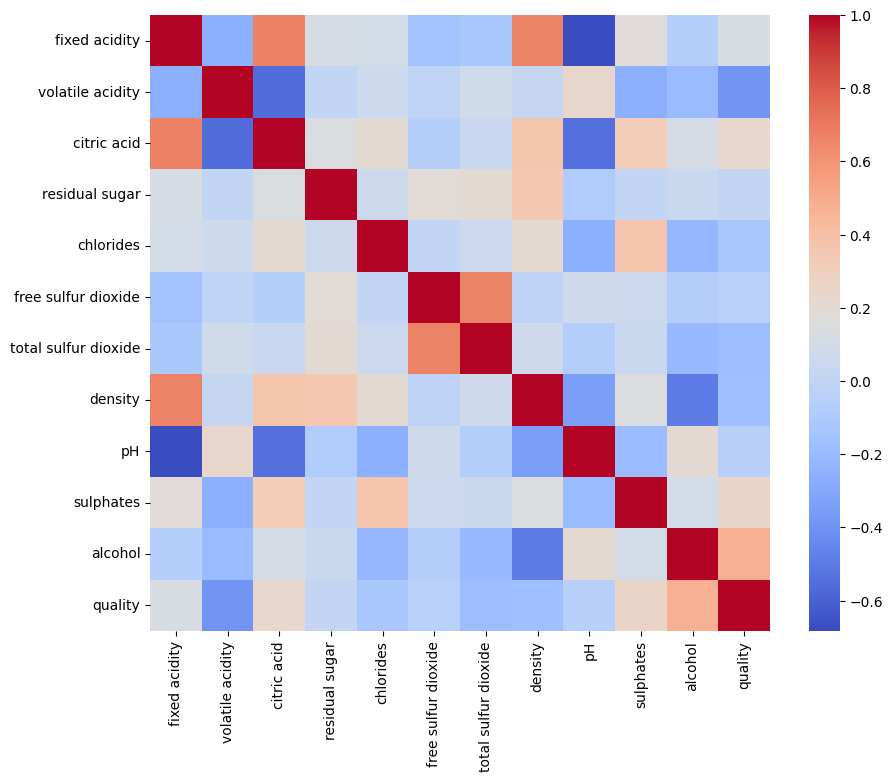

In [22]:
import seaborn as sb

plt.figure(figsize = (10, 8))
sb.heatmap(wine.corr(), annot = False, cmap = "coolwarm")
plt.show()

From the heatmap above, There do not appear to be very many variables that have very strong correlations. However, it does show that the pairs of [PH, Fixed Acidity] and [Citric Acid, Volatile Acidity] do have a fairly strong negative correlation (about -0.6 according to the index to the right of the figure). Also, pairs such as [Citric Acid, Fixed Acidity], [Total SO_2, Free SO_2], and [Fixed Acidity, Density] appear to have a fairly strong positive correlation (each between 0.5 and 0.6 according to the index to the right of the figure).

One thing also worth noting is that volatile acidity appears to have a somewhat noticeable negative correlation with quality, not very strong but still noticeable. This may show that it is common for a wine that has good quality to have a lower volatile acidity. Similarly, the heatmap suggests that alcohol has a somewhat noticeable positive correlation with quality, not very strong but still noticeable. This may show that it is common for a wine that has good quality to have higher alcohol.

### 4.) Questions and Visualizations

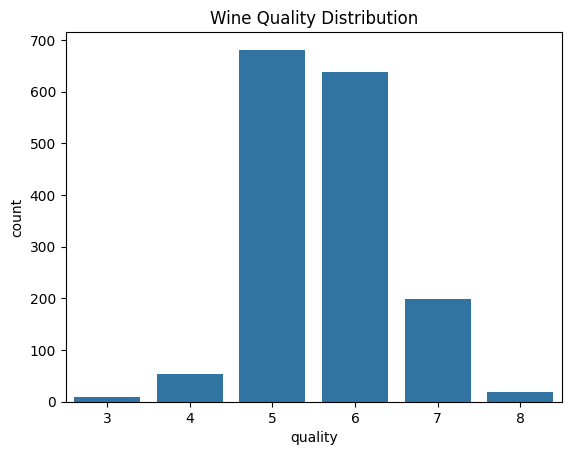

In [13]:
sb.countplot(x = "quality", data = wine)
plt.title("Wine Quality Distribution")
plt.show()

Observation Above:

A vast majority of wines in the dataset are have a quality rating of 5 or 6. Every other quality rating seems to be greatly under represented.
Dataset is imbalanced which could cause problems with the analysis process. 

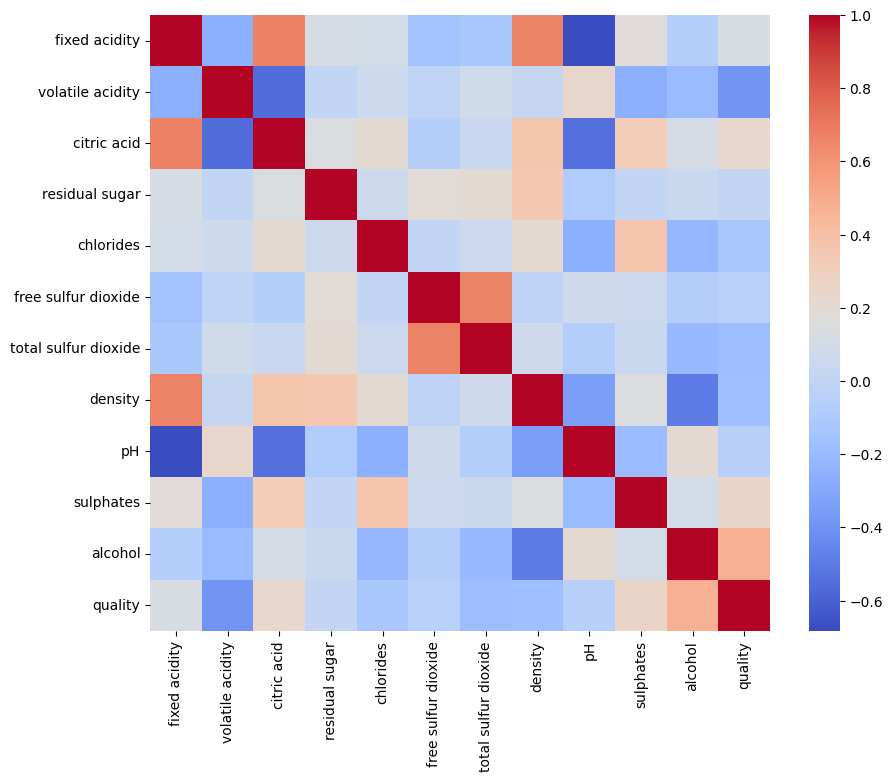

In [30]:
import seaborn as sb

plt.figure(figsize = (10, 8))
sb.heatmap(wine.corr(), annot = False, cmap = "coolwarm")
plt.show()

Obervation Above:

There appear to be some attributes that have a noticeable correlation between them.

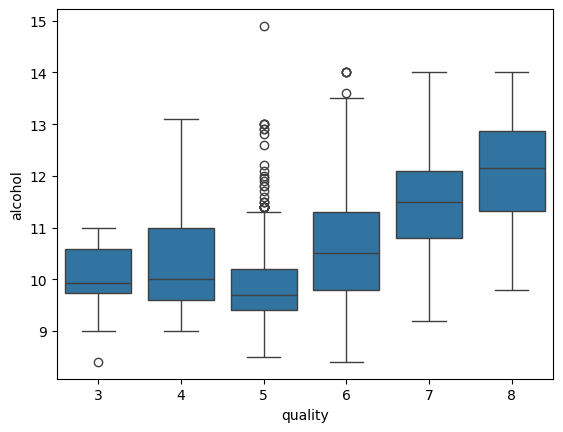

In [31]:
sb.boxplot(x = "quality", y = "alcohol", data = wine)
plt.show()

Observation Above:

Higher quality wines are positively correlated with alcohol content.

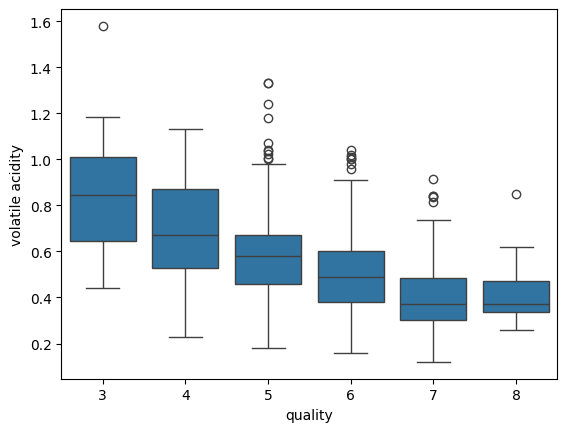

In [32]:
sb.boxplot(x = "quality", y = "volatile acidity", data = wine)
plt.show()

Observation Above: 

Higher quality wines are negatively correlated with volatile acidity.

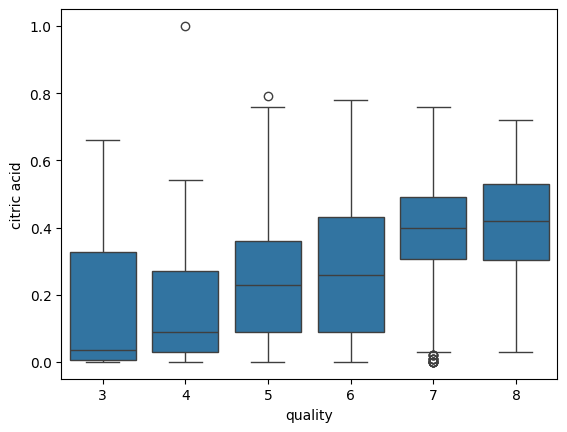

In [33]:
sb.boxplot(x = "quality", y = "citric acid", data = wine)
plt.show()

Observation Above: 

Higher quality wines are postively correlated with citric acid.

Questions that arise from visualizing the data:

1.) Does the dataset have equal representation for each possible output?

    -> No, dataset over represents "average quality" (quality rating either 5 or 6) and under represents "poor quality" (quality rating under 5) and "high quality" (quality rating over 6).

2.) Are there any attribute that have strong correlations between them?

    -> Yes, there are a few pairs of attributes that show positive correlations and there are also a few pairs that show negative correlations.

3.) Does alcohol content affect wine quality?

    -> Yes, data shows positive correlation between these attributes.

4.) Does volatile acidity affect wine quality?

    -> Yes, data shows negative correlation between these attributes.

5.) If the pairs of [Volatile Acidity, Citric Acid] and [Volatile Acidity, Quality] both show negative correlations, why does it seem that the pair of [Citric Acid, Quality] has a very low correlation?

    -> This may appear so from the lattice point on the heatmap where these two attributes meet, however, when looking at a boxplot comparing the two attributes, it shows that there may be a positive correlation between citric acid and quality.

# Task 2: Regression Analysis

First import necessary libraries for Regression analysis. Then do multiple linear regression using PH as the response and all other atrributes as predictors. Then print out the data found.

In [38]:
import statsmodels.api as sm

x = wine.drop("pH", axis = 1)
y = wine["pH"]

x = sm.add_constant(x)

model = sm.OLS(y, x).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     pH   R-squared:                       0.701
Model:                            OLS   Adj. R-squared:                  0.698
Method:                 Least Squares   F-statistic:                     337.5
Date:                Sat, 02 May 2026   Prob (F-statistic):               0.00
Time:                        22:54:41   Log-Likelihood:                 1683.1
No. Observations:                1599   AIC:                            -3342.
Df Residuals:                    1587   BIC:                            -3278.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  -60.5270 

### 1.) Statistical Significance Between Predictors and the Response

Statistical significance indicates that an effect of one variable on another variable was likely not by accident. To find statistical significance, we use the table above and look at the column labeled P > |t| and examine the values of this column for each attribute. If this value is less than 0.05 then there is statistical significance between this predictor and the response, if this value is greater than or equal to 0.05 then there is no statistical significance between this predictor and the response.

According to the table, the only predictors that have no statistical significance to PH are Volatile Acidity and Citric Acid.

### 2.) Diagnostic Plots

Create diagnostic plots of the linear regression fit to check validity of the model.

    Fitted Values ->     Predicted Values = yHat
    Residual ->          Error =            y - yHat

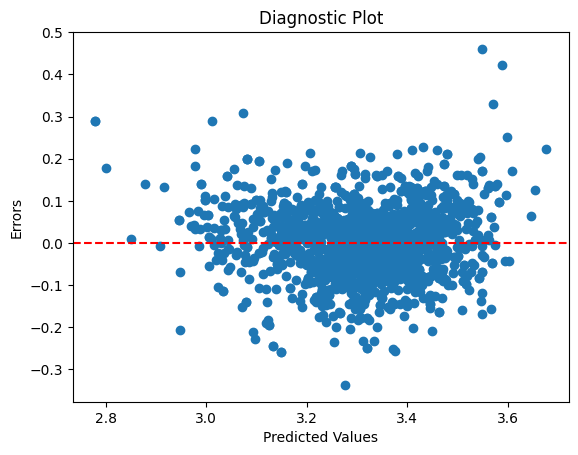

In [42]:
err = model.resid
predictions = model.fittedvalues

plt.scatter(predictions, err)
plt.axhline(0, color = 'red', linestyle = '--')
plt.xlabel("Predicted Values")
plt.ylabel("Errors")
plt.title("Diagnostic Plot")
plt.show()

The plot of the predicted values with their errors shows a very random spread. The overall shape of the spread is a bit ovular with a "flatter" top side. This may suggest a slightly imperfect, but still with good, linear model. 

Now create a histogram of the residuals.

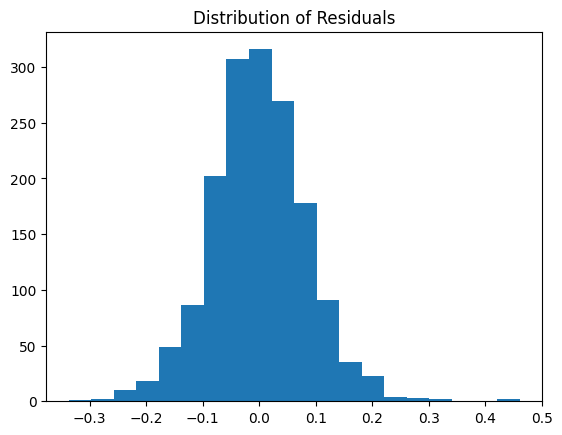

In [50]:
plt.hist(err, bins = 20)
plt.title("Distribution of Residuals")
plt.show()

The histogram above shows the plot of errors in the data. The distribution is bell curve shaped and centered at 0.0, with what appears to be one of very few outliers at about 0.45. 

The shape and the mean of this distribution suggest that the model is sufficient, but with a few minor imperfections.

In conclusion, this model appears to meet a majority of the assumptions of linear regression but with a few potential anomalies.

### 3.) Linear Regression Models

Explore what interaction effects of certain attributes in the data have on alcohol in the dataset.

In [51]:
model1X = wine[["density", "residual sugar", "volatile acidity"]]
model1Y = wine["alcohol"]

model1X = sm.add_constant(model1X)
model1 = sm.OLS(model1Y, model1X).fit()

print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                alcohol   R-squared:                       0.337
Model:                            OLS   Adj. R-squared:                  0.336
Method:                 Least Squares   F-statistic:                     270.0
Date:                Sun, 03 May 2026   Prob (F-statistic):          1.02e-141
Time:                        12:25:00   Log-Likelihood:                -2041.7
No. Observations:                1599   AIC:                             4091.
Df Residuals:                    1595   BIC:                             4113.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              337.1528     12.264  

For the model above, here are reasons for the three attributes chosen:

Density -> coef = -327.6761, P>|t| = 0.000:
 
Negative correlation with alcohol.

Residual Sugar -> coef = 0.1879, P>|t| = 0.000:

Positive correlation with alchol.

Volatile Acidity -> coef = -1.1307, P>|t| = 0.000:

Negative correlation with alcohol.

    R^2 =       0.337
    Adj R^2 =   0.336
    P Values =  Density, Residual Sugar, Volatile Acidity

In [52]:
wine["density sugar"] = wine["density"] * wine["residual sugar"]

model2X = wine[["density", "residual sugar", "density sugar"]]
model2Y = wine["alcohol"]

model2X = sm.add_constant(model2X)
model2 = sm.OLS(model2Y, model2X).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                alcohol   R-squared:                       0.302
Model:                            OLS   Adj. R-squared:                  0.301
Method:                 Least Squares   F-statistic:                     230.5
Date:                Sun, 03 May 2026   Prob (F-statistic):          3.25e-124
Time:                        12:25:00   Log-Likelihood:                -2082.2
No. Observations:                1599   AIC:                             4172.
Df Residuals:                    1595   BIC:                             4194.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            311.6237     18.942     16.

For the model above, here is the reason the following variables were chosen:

Density -> coef = -302.7113, P>|t| = 0.000:

Negative correlation with alcohol.

Residual Sugar -> coef = 10.7002, P>|t| = 0.048

Positive correlation with alcohol.

Density Sugar -> 

Want to see if the combination of these attributes has an effect on alcohol.

Observation:

Density Sugar -> P>|t| = 0.052

Has no statistical significance to alcohol.

    R^2 =       0.302
    Adj R^2 =   0.301
    P values =  Density, Residual Sugar

In [53]:
wine["sulphate acid"] = wine["sulphates"] * wine["citric acid"]

model3X = wine[["sulphates", "citric acid", "volatile acidity", "sulphate acid"]]
model3Y = wine["alcohol"]

model3X = sm.add_constant(model3X)
model3 = sm.OLS(model3Y, model3X).fit()

print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                alcohol   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     19.25
Date:                Sun, 03 May 2026   Prob (F-statistic):           1.77e-15
Time:                        12:25:00   Log-Likelihood:                -2332.4
No. Observations:                1599   AIC:                             4675.
Df Residuals:                    1594   BIC:                             4702.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               10.4562      0.244  

For the model above, here are reasons each attribute was chosen:

Want to find potential trends related to different chemical interactions within the data.

Sulphates -> coef = 0.8821, P>|t| = 0.003

Positive correlation with alcohol.

Citric Acid -> coef = 1.0604, P>|t| = 0.040

Positive correlation with alcohol.

Volatile Acidity -> coef -1.1121, P>|t| = 0.000

Negative correlation with alcohol.

Sulphate Acid -> 

Want to see if the combination of these attribute has an effect on alcohol.

Obesrvation:

Sulphate Acid -> coef = -1.6652, P>|t| = 0.020

Has a negative correlation with alcohol.

    R^2 =       0.046
    Adj R^2 =   0.044
    P Values =  Sulphates, Citric Acid, Volatile Acidity, Sulphate Acid

Conclusion:

Model 1 had the highest R^2 value among the three models at 0.337, all variables are significant indicating all of the variables used have correlation with alcohol content.

Model 2 has a lower R^2 value of 0.0302, not every variable used was significant. This indicates that the interaction between residual sugar and density may not be important in predicting alcohol content.

Model 3 had the lowest of the R^2 values at 0.046, all variables were statistically significant, but the R^2 value indicates that sulphates, citric acid, volatile acidity, and sulphate acid does not reveal much in the way of alcohol content.

Model 1 Overall was the best model.

# Task 3a. K-Means Clustering

Import sklearn libraries to prepare the date for K Means Clustering.

In [55]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

x = wine.drop("quality", axis = 1)

s = StandardScaler()

xScaled = s.fit_transform(x)

sse = []

for k in range(2, 9):
    km = KMeans(n_clusters = k, max_iter = 20, random_state = 42, n_init = 10)
    km.fit(xScaled)

    err = km.inertia_
    sse.append(err)

    print(f"For k = {k} After 20 iterations: Error = {err:.5f}")

For k = 2 After 20 iterations: Error = 16549.09337
For k = 3 After 20 iterations: Error = 14782.92971
For k = 4 After 20 iterations: Error = 13211.78365
For k = 5 After 20 iterations: Error = 11918.92522
For k = 6 After 20 iterations: Error = 10744.02243
For k = 7 After 20 iterations: Error = 9900.96096
For k = 8 After 20 iterations: Error = 9428.79616


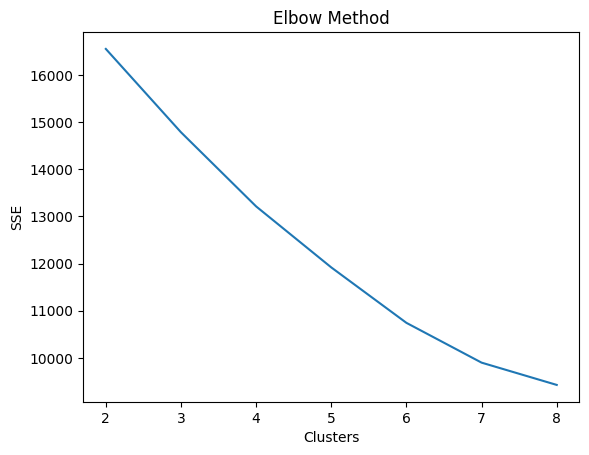

In [56]:
import matplotlib.pyplot as plt

kVals = list(range(2, 9))

plt.plot(kVals, sse)
plt.xlabel("Clusters")
plt.ylabel("SSE")
plt.title("Elbow Method")
plt.show()

After reviewing the plot, there is no clear elbow point for number of clusters. However, the "flattest" part of the slope is between 7 and 8 clusters, so the best value for k would probably be 7 since 8 does not reduce the SSE by much more and SSE for 7 clusters is the second lowest on the plot.

    k = 7

# Task 3b. Agglomerative Hierarchical Clustering

Import the libraries to construct the dendrogram for the data.



Do for Single Link Clustering:

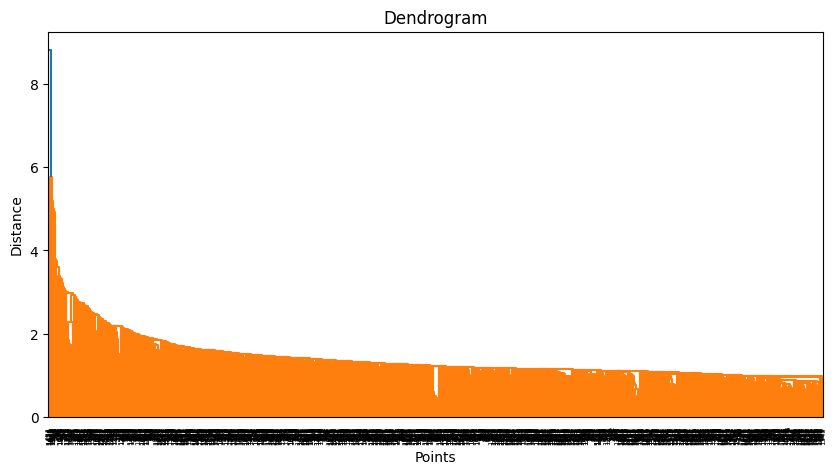

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram

z = linkage(xScaled, method = 'single', metric = 'euclidean')

plt.figure(figsize = (10, 5))
dendrogram(z)
plt.title("Dendrogram")
plt.xlabel("Points")
plt.ylabel("Distance")
plt.show()

Form clusters and calculate silhouette score:

In [60]:
from scipy.cluster.hierarchy import fcluster
from sklearn.metrics import silhouette_score

clusters = fcluster(z, 3, criterion = 'maxclust')

score = silhouette_score(xScaled, clusters)
print("Single Link Score: ", score)

Single Link Score:  0.6625938820646788


Do for Complete Link Clustering:

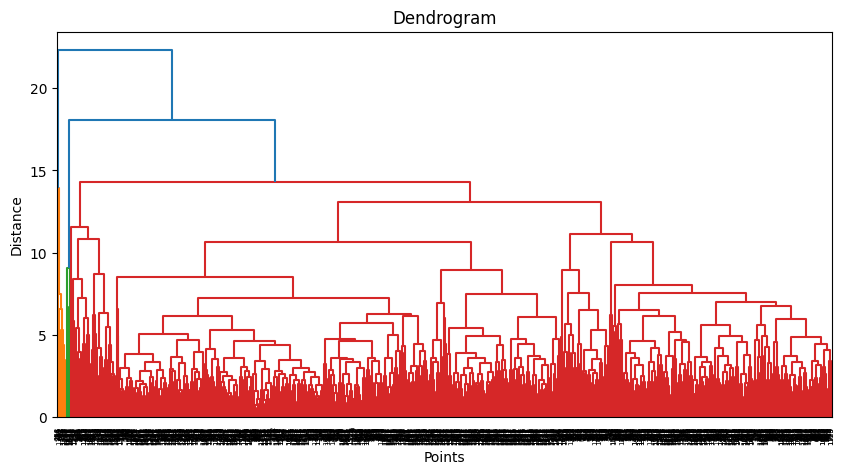

In [61]:
z = linkage(xScaled, method = 'complete', metric = 'euclidean')

plt.figure(figsize = (10, 5))
dendrogram(z)
plt.title("Dendrogram")
plt.xlabel("Points")
plt.ylabel("Distance")
plt.show()

Form clusters and calculate silhouette scores:

In [63]:
from scipy.cluster.hierarchy import fcluster
from sklearn.metrics import silhouette_score

clusters = fcluster(z, 3, criterion = 'maxclust')

score = silhouette_score(xScaled, clusters)
print("Complete Link Score: ", score)

Complete Link Score:  0.5441454462554723


Silhouette Score for Single Link Hierarchical Clustering turned out to be better than Complete Link Hierarchical Clustering.

    Complete:   0.5441
    Single:     0.6626

    Single > Complete